Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.LANF2U_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.LANF2U_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 37s 113ms/step - accuracy: 0.7169 - loss: 0.5187 - mean_io_u: 0.3502 - val_accuracy: 0.7270 - val_loss: 0.5051 - val_mean_io_u: 0.3500
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.7550 - loss: 0.4722 - mean_io_u: 0.3502 - val_accuracy: 0.7750 - val_loss: 0.4575 - val_mean_io_u: 0.3500
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.7822 - loss: 0.4426 - mean_io_u: 0.3502 - val_accuracy: 0.7900 - val_loss: 0.4298 - val_mean_io_u: 0.3500
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.7930 - loss: 0.4274 - mean_io_u: 0.3502 - val_accuracy: 0.8130 - val_loss: 0.3984 - val_mean_io_u: 0.3500
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.8075 - loss: 0.4050 - mean_io_u: 0.3502 - val_accuracy: 0.8241 - val_loss: 0.3864 - val_mean_io_

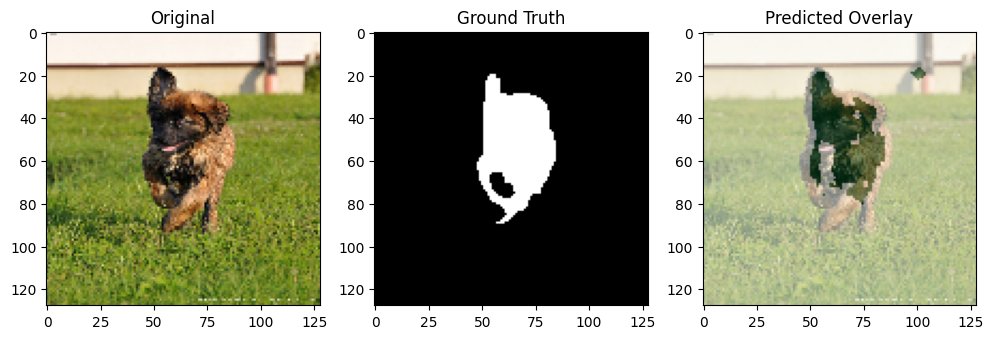

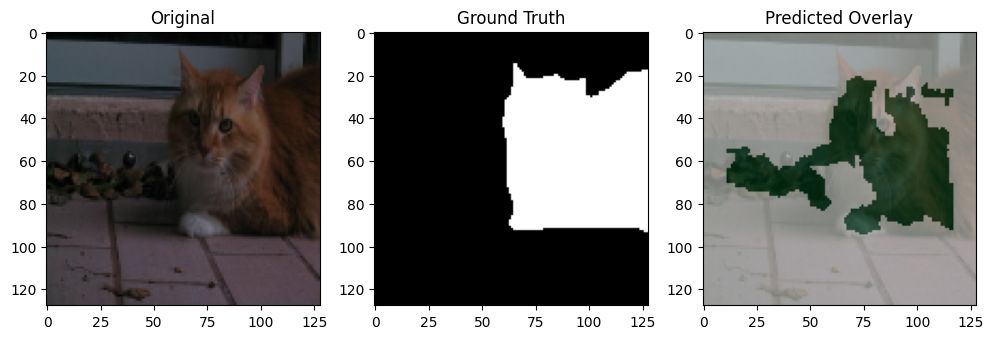

In [1]:
# Install and load dataset
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

def preprocess(sample):
    image = tf.image.resize(sample['image'], (128, 128)) / 255.0
    mask = tf.image.resize(sample['segmentation_mask'], (128, 128), method='nearest')
    mask = tf.cast(mask == 1, tf.float32)
    return image, mask

train = dataset['train'].map(preprocess).batch(16).prefetch(tf.data.AUTOTUNE)
val = dataset['test'].map(preprocess).batch(16).prefetch(tf.data.AUTOTUNE)

# Build U-Net
inputs = tf.keras.Input((128,128,3))
c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
p1 = tf.keras.layers.MaxPooling2D()(c1)
c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
p2 = tf.keras.layers.MaxPooling2D()(c2)
bn = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
u1 = tf.keras.layers.UpSampling2D()(bn)
u1 = tf.keras.layers.Concatenate()([u1, c2])
u1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
u2 = tf.keras.layers.UpSampling2D()(u1)
u2 = tf.keras.layers.Concatenate()([u2, c1])
u2 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(u2)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)])

# Train
history = model.fit(train, validation_data=val, epochs=10)

# Save overlays
for images, masks in val.take(1):
    preds = model.predict(images)
    for i in range(2):
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(images[i])
        axes[0].set_title('Original')
        axes[1].imshow(masks[i,:,:,0], cmap='gray')
        axes[1].set_title('Ground Truth')
        axes[2].imshow(images[i])
        axes[2].imshow(preds[i,:,:,0] > 0.5, alpha=0.5, cmap='Greens')
        axes[2].set_title('Predicted Overlay')
        plt.savefig(f'val_result_{i}.png')
        plt.show()


Epoch 1/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.8411 - loss: 0.3503 - mean_io_u_1: 0.3502 - val_accuracy: 0.8410 - val_loss: 0.3491 - val_mean_io_u_1: 0.3500
Epoch 2/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8441 - loss: 0.3440 - mean_io_u_1: 0.3502 - val_accuracy: 0.8503 - val_loss: 0.3360 - val_mean_io_u_1: 0.3500
Epoch 3/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.8472 - loss: 0.3388 - mean_io_u_1: 0.3502 - val_accuracy: 0.8451 - val_loss: 0.3516 - val_mean_io_u_1: 0.3500
Epoch 4/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.8504 - loss: 0.3324 - mean_io_u_1: 0.3502 - val_accuracy: 0.8485 - val_loss: 0.3420 - val_mean_io_u_1: 0.3500
Epoch 5/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.8508 - loss: 0.3318 - mean_io_u_1: 0.3502 - val_accuracy: 0.8499 - val_loss: 0.3371 - val_mean_io_u_1: 0.3500
Epoch 6/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.8532 - loss: 0.3275 - mean_io_u_1: 0.3502

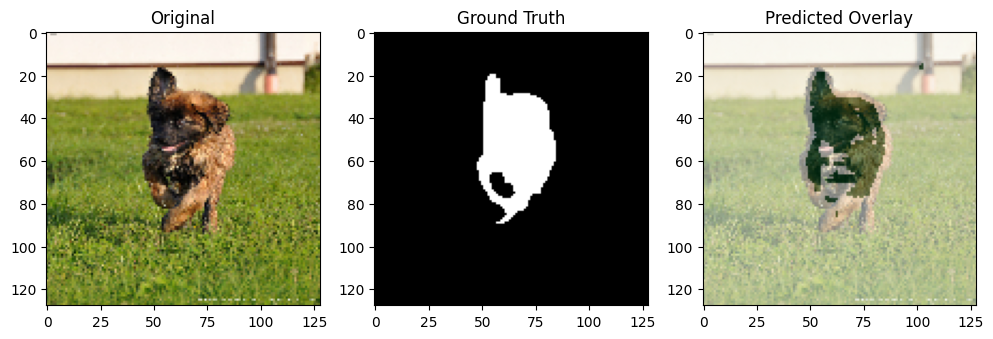

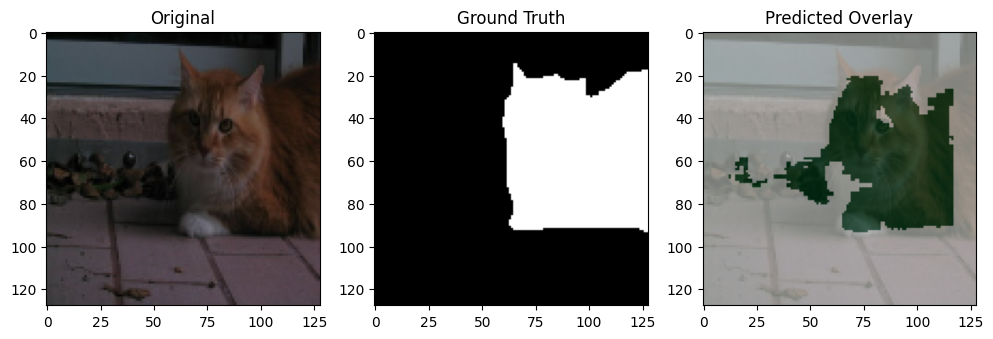

In [2]:
# Data augmentation
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    image = tf.image.random_brightness(image, 0.1)
    return image, mask

train_aug = dataset['train'].map(preprocess).map(augment).batch(16).prefetch(tf.data.AUTOTUNE)

# Retrain with augmentation
model2 = tf.keras.Model(inputs, outputs)
model2.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)])

history2 = model2.fit(train_aug, validation_data=val, epochs=25)

# Save better overlays
for images, masks in val.take(1):
    preds = model2.predict(images)
    for i in range(2):
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(images[i])
        axes[0].set_title('Original')
        axes[1].imshow(masks[i,:,:,0], cmap='gray')
        axes[1].set_title('Ground Truth')
        axes[2].imshow(images[i])
        axes[2].imshow(preds[i,:,:,0] > 0.5, alpha=0.5, cmap='Greens')
        axes[2].set_title('Predicted Overlay')
        plt.savefig(f'val_result_v2_{i}.png')
        plt.show()


In [3]:
# Calculate real IoU manually
import numpy as np

iou_scores = []
for images, masks in val:
    preds = model2.predict(images, verbose=0)
    preds_binary = (preds > 0.5).astype(float)
    masks_np = masks.numpy()
    intersection = np.logical_and(preds_binary[:,:,:,0], masks_np[:,:,:,0])
    union = np.logical_or(preds_binary[:,:,:,0], masks_np[:,:,:,0])
    iou = np.sum(intersection) / np.sum(union)
    iou_scores.append(iou)

print(f"Real Mean IoU: {np.mean(iou_scores):.4f}")


Real Mean IoU: 0.6156


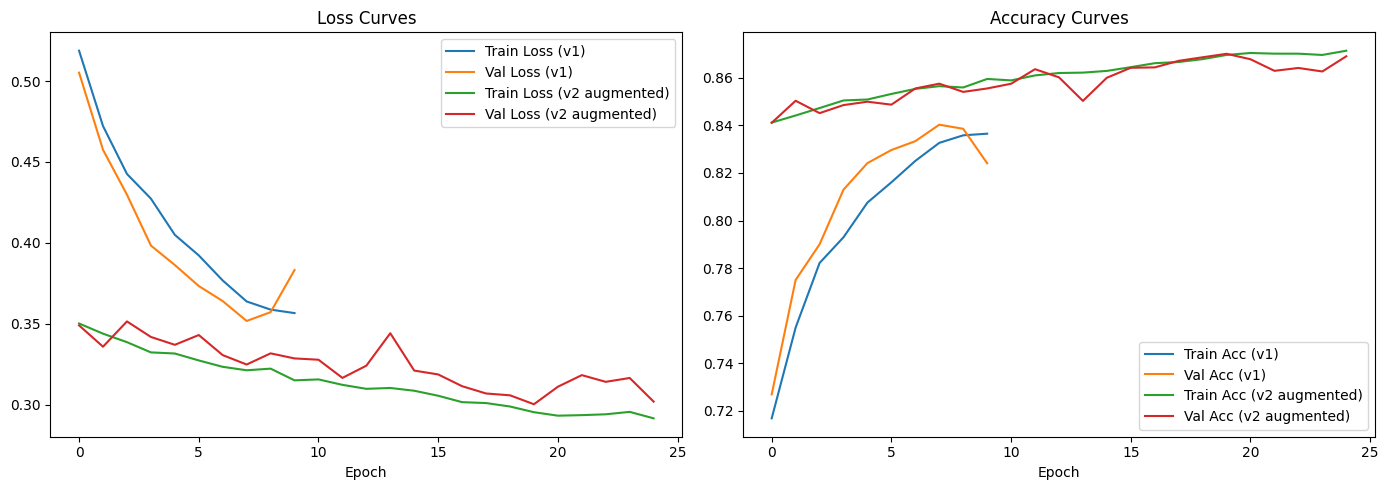

Saved training_curves.png


In [4]:
# Plot and save training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss (v1)')
axes[0].plot(history.history['val_loss'], label='Val Loss (v1)')
axes[0].plot(history2.history['loss'], label='Train Loss (v2 augmented)')
axes[0].plot(history2.history['val_loss'], label='Val Loss (v2 augmented)')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc (v1)')
axes[1].plot(history.history['val_accuracy'], label='Val Acc (v1)')
axes[1].plot(history2.history['accuracy'], label='Train Acc (v2 augmented)')
axes[1].plot(history2.history['val_accuracy'], label='Val Acc (v2 augmented)')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved training_curves.png")

In [5]:
from google.colab import files

# Download all result files
files.download('training_curves.png')
files.download('val_result_v2_0.png')
files.download('val_result_v2_1.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
uploaded = files.upload()

Saving outdoor.heic to outdoor.heic
Saving room.JPG to room.JPG


In [7]:
!pip install pillow-heif -q

from pillow_heif import register_heif_opener
register_heif_opener()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 100.8 MB/s eta 0:00:00


In [13]:
from PIL import Image
import numpy as np

ValueError: Format 'heic' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

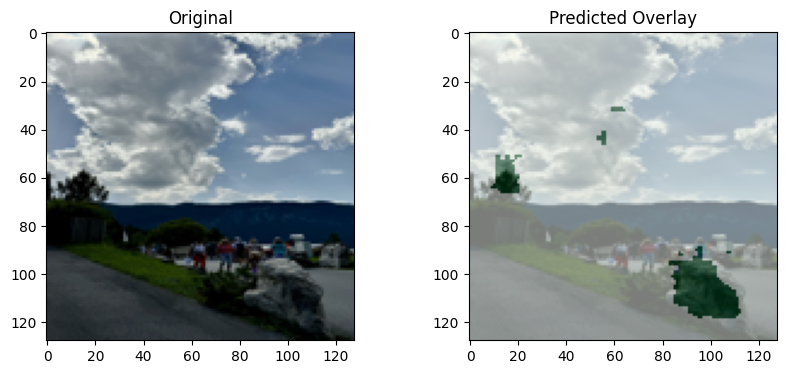

In [17]:
from PIL import Image
from pillow_heif import register_heif_opener
import numpy as np
import matplotlib.pyplot as plt

register_heif_opener()

def predict_custom(image_path, save_path):
    img = Image.open(image_path).convert('RGB').resize((128, 128))
    img_array = np.array(img) / 255.0
    img_input = np.expand_dims(img_array, 0)
    pred = model2.predict(img_input, verbose=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_array)
    axes[0].set_title('Original')
    axes[1].imshow(img_array)
    axes[1].imshow(pred[0,:,:,0] > 0.5, alpha=0.5, cmap='Greens')
    axes[1].set_title('Predicted Overlay')
    plt.savefig(save_path, dpi=150)
    plt.show()

for name in uploaded.keys():
    predict_custom(name, f'custom_{name}')

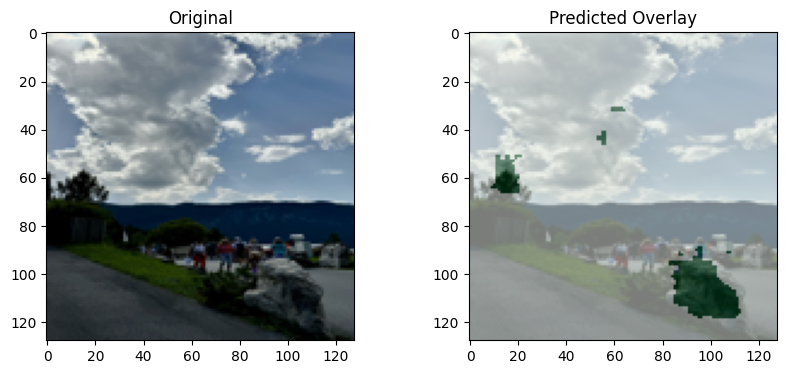

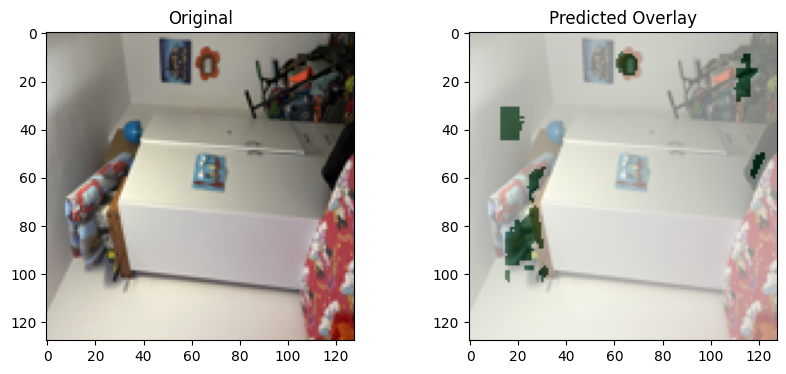

In [18]:
for name in uploaded.keys():
    save_name = name.rsplit('.', 1)[0] + '.png'
    predict_custom(name, f'custom_{save_name}')

In [19]:
from google.colab import files
files.download('custom_outdoor.png')
files.download('custom_room.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>